In [2]:
CSV_PATH = "../../classification/output/props_with_predictions.csv"

import pandas as pd

df = pd.read_csv(CSV_PATH)
df.head()

,image,label,intensity_mean_red,intensity_std_red,intensity_p10_red,intensity_p20_red,intensity_p30_red,intensity_p40_red,intensity_p50_red,intensity_p60_red,...,red_glcm_homogeneity_mean,red_glcm_homogeneity_std,red_glcm_ASM_mean,red_glcm_ASM_std,red_glcm_energy_mean,red_glcm_energy_std,red_glcm_correlation_mean,red_glcm_correlation_std,prediction,probability
0,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...,1,147.103383,32.072746,111.0,115.0,120.0,129.0,142.0,154.0,...,0.326559,0.043288,0.039981,0.010707,0.197935,0.028340,0.555732,0.150835,1,0.894
1,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...,2,150.457866,28.015445,113.0,121.0,133.0,145.0,153.0,158.0,...,0.441485,0.061271,0.078010,0.018478,0.277095,0.035048,0.655097,0.169546,1,0.896
2,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...,3,171.629728,38.628180,130.0,137.0,144.0,153.0,164.0,177.0,...,0.338246,0.072152,0.025135,0.009646,0.155089,0.032903,0.573503,0.240553,1,0.896
3,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...,4,148.459975,30.194635,112.0,118.0,126.0,135.0,146.0,155.0,...,0.323109,0.070574,0.023316,0.009171,0.149132,0.032795,0.651910,0.173442,1,0.896
4,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...,5,160.807558,35.738544,118.0,126.0,135.0,147.0,158.0,169.0,...,0.417645,0.072211,0.044316,0.012153,0.208290,0.030528,0.632489,0.196033,1,0.898


In [7]:
# Count cells of each class per image
counts = (
    df.groupby(["image", "prediction"])
      .size()
      .unstack(fill_value=0)
)

# Total number of classified cells
counts["total"] = counts.sum(axis=1)

# Percentages
for cls in counts.columns[:-1]:  # exclude "total"
    counts[f"{cls}_percent"] = 100 * counts[cls] / counts["total"]

# Convert image index back to a column
summary = counts.reset_index()

print(summary)

prediction                                              image     0     1  \
0           0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...   194  5040   
1           1.3_P301S+PLA_BS_AT8_E2_first bottom_2026-04-2...  1209   360   
2           1.3_P301S+PLA_HC_AT8_E2_first bottom_2026-04-2...  3548    64   
3           1.3_P301S+PLA_MC_AT8_E2_first bottom_2026-04-2...  4022   231   
4           31.3-26.2.25_WT+PLA_BS_AT8_delta1_first_2026-0...   156  3054   
5           31.3-26.2.25_WT+PLA_HC_AT8_delta1_fifth_2026-0...   144  4995   
6           31.3-26.2.25_WT+PLA_MC_AT8_delta1_first_2026-0...   122  3669   
7           53234M_CHST11KO_HC_AT8_epsilon1_first_2026-04-...    56  1708   
8           64U-J9910_CHST11KO_BS_AT8_delta4_first_2026-04...   114  3363   
9           64U-J9910_CHST11KO_MC_AT8_delta4_first_2026-04...   189  4102   
10          F2445_CHST11KO+P301S_BS_AT8_epsilon1_fourth_20...   105  2393   
11          F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...   112  3886   

In [13]:
# Counts per class
counts = (
    df.groupby(["image", "prediction"])
      .size()
      .unstack(fill_value=0)
)

counts["total_cells"] = counts.sum(axis=1)

# Percentages
# skip total_cells
for cls in counts.columns[:-1]:
    counts[f"{cls}_percent"] = 100 * counts[cls] / counts["total_cells"]

# Mean and std probability per class
prob_stats = (
    df.groupby(["image", "prediction"])["probability"]
      .agg(["mean", "std"])
      .unstack()
)

# Flatten the MultiIndex columns
prob_stats.columns = [
    f"{cls}_{stat}_probability"
    for stat, cls in prob_stats.columns
]

# Combine everything
summary = (
    counts
    .join(prob_stats)
    .reset_index()
)

summary

,image,0,1,total_cells,0_percent,1_percent,0_mean_probability,1_mean_probability,0_std_probability,1_std_probability
0,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...,194,5040,5234,3.706534,96.293466,0.296464,0.870631,0.118850,0.049561
1,1.3_P301S+PLA_BS_AT8_E2_first bottom_2026-04-2...,1209,360,1569,77.055449,22.944551,0.037793,0.941350,0.080902,0.113248
2,1.3_P301S+PLA_HC_AT8_E2_first bottom_2026-04-2...,3548,64,3612,98.228128,1.771872,0.012877,0.849969,0.047228,0.172856
3,1.3_P301S+PLA_MC_AT8_E2_first bottom_2026-04-2...,4022,231,4253,94.568540,5.431460,0.012515,0.914900,0.049838,0.139166
4,31.3-26.2.25_WT+PLA_BS_AT8_delta1_first_2026-0...,156,3054,3210,4.859813,95.140187,0.245897,0.894726,0.148694,0.080101
5,31.3-26.2.25_WT+PLA_HC_AT8_delta1_fifth_2026-0...,144,4995,5139,2.802102,97.197898,0.256250,0.887723,0.144825,0.069918
6,31.3-26.2.25_WT+PLA_MC_AT8_delta1_first_2026-0...,122,3669,3791,3.218148,96.781852,0.254754,0.903935,0.175851,0.060034
7,53234M_CHST11KO_HC_AT8_epsilon1_first_2026-04-...,56,1708,1764,3.174603,96.825397,0.274750,0.875607,0.164687,0.057492
8,64U-J9910_CHST11KO_BS_AT8_delta4_first_2026-04...,114,3363,3477,3.278689,96.721311,0.273281,0.907561,0.139358,0.077585
9,64U-J9910_CHST11KO_MC_AT8_delta4_first_2026-04...,189,4102,4291,4.404568,95.595432,0.271598,0.894782,0.149042,0.066176


In [15]:
summary.to_csv("../../classification/output/red_summary_classification.csv", index=False)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
       <Axes: >], dtype=object)

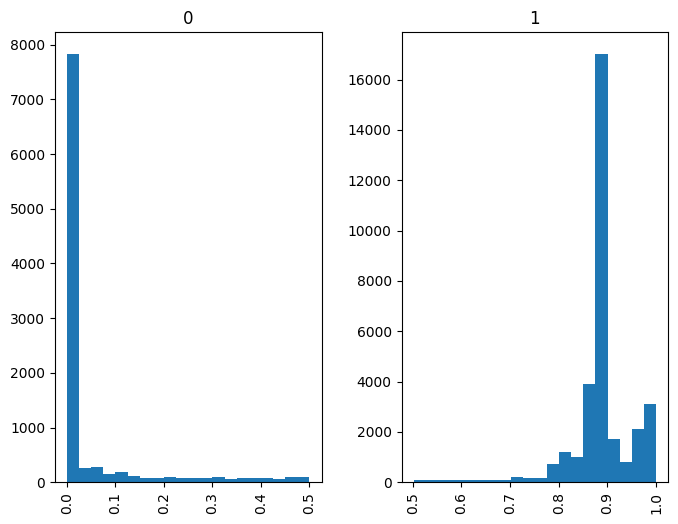

In [16]:
df.hist(column="probability", by="prediction", bins=20, figsize=(12, 6), layout=(1, 3))